In [8]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


In [9]:
electron_weights = pd.read_csv("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC/Electron_LIW.csv")
muon_weights = pd.read_csv("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC/Muon_LIW.csv")
nc_weights = pd.read_csv("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC/NC_LIW.csv")
tau_weights = pd.read_csv("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC/Tau_LIW.csv")


In [10]:

electron_neutrino = electron_weights.loc[
    electron_weights["initialType"] > 0
].copy()

electron_antineutrino = electron_weights.loc[
    electron_weights["initialType"] < 0
].copy()

electron_antineutrino["final_weight"] = electron_antineutrino["oneweight_x100"] / len(electron_antineutrino)
electron_neutrino["final_weight"] = electron_neutrino["oneweight_x100"] / len(electron_neutrino)



In [11]:
electron_antineutrino.head()

,RunID,SubrunID,EventID,SubEventID,energy,zenith,azimuth,finalStateX,finalStateY,columnDepth,injectionMode,injectionRadius,injectionConfigSource,initialType,finalType1,finalType2,oneweight,survivalProb,oneweight_x100,final_weight
100,7,4294967295,101,0,3930.385395,2.239810,1.733151,0.286333,0.880570,1.143140e+06,range,1100.0,lic,-12,-11,-2000001006,5.612785e+08,0.975868,5.612785e+10,81950.432802
101,7,4294967295,102,0,138.902593,1.174191,5.199103,0.403598,0.879118,3.555688e+05,range,1100.0,lic,-12,-11,-2000001006,4.031166e+04,1.004910,4.031166e+06,5.885774
102,7,4294967295,103,0,237.807399,2.943374,2.405139,0.131558,0.759711,4.331585e+05,range,1100.0,lic,-12,-11,-2000001006,4.376162e+05,0.997082,4.376162e+07,63.894906
103,7,4294967295,104,0,943.966224,1.417675,4.120636,0.199702,0.016414,5.780458e+05,range,1100.0,lic,-12,-11,-2000001006,5.524378e+07,1.002330,5.524378e+09,8065.963109
104,7,4294967295,105,0,249.687526,0.485035,2.221917,0.167358,0.809882,4.408984e+05,range,1100.0,lic,-12,-11,-2000001006,4.095265e+05,1.004039,4.095265e+07,59.793622


In [12]:
electron_antineutrino["final_weight"] = electron_antineutrino["final_weight"] * electron_antineutrino["survivalProb"]
electron_neutrino["final_weight"] = electron_neutrino["final_weight"] * electron_neutrino["survivalProb"]



## IceCube-Gen2-style effective area by angular band

The plot below follows the left-panel style in the reference figure: energy on the x-axis, effective area on the y-axis, and one curve per angular band. Here the available direction variable is local `zenith`, so the plotted angular coordinate is `cos(zenith)`. For a local detector coordinate this plays the same role as the `sin(delta)` binning in the reference-style plot.

The weight used here is `final_weight = oneweight_x100 / N_generated_in_sample * survivalProb`. Effective area is computed as

$$
A_{\mathrm{eff}}(E, \Omega) = \frac{\sum_i w_i}{\Delta E\,\Delta\Omega},
$$

with $\Delta\Omega = 2\pi\Delta\cos(\theta)$ for each zenith band.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

WEIGHT_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC")
WEIGHT_FILES = {
    "electron_cc": WEIGHT_DIR / "Electron_LIW.csv",
    "muon_cc": WEIGHT_DIR / "Muon_LIW.csv",
    "tau_cc": WEIGHT_DIR / "Tau_LIW.csv",
    "neutral_current": WEIGHT_DIR / "NC_LIW.csv",
}

PID_TO_FLAVOR = {
    12: "e",
    14: "mu",
    16: "tau",
    -12: "e_bar",
    -14: "mu_bar",
    -16: "tau_bar",
}

FLAVOR_LABELS = {
    "e": r"$\nu_e + \bar{\nu}_e$",
    "mu": r"$\nu_\mu + \bar{\nu}_\mu$",
    "tau": r"$\nu_\tau + \bar{\nu}_\tau$",
}


def load_weight_table(weight_files=WEIGHT_FILES):
    frames = []
    for sample, csv_path in weight_files.items():
        df = pd.read_csv(csv_path)
        df["sample"] = sample
        df["interaction"] = "NC" if sample == "neutral_current" else "CC"
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)

    numeric_columns = ["energy", "zenith", "initialType", "oneweight_x100", "survivalProb"]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df["pid"] = df["initialType"].astype("Int64")
    df["flavor_particle"] = df["pid"].map(PID_TO_FLAVOR)
    df["flavor"] = df["flavor_particle"].str.replace("_bar", "", regex=False)
    df["cos_zenith"] = np.cos(df["zenith"])

    generated_per_particle_sample = df.groupby(["sample", "pid"])["pid"].transform("size")
    df["final_weight"] = df["oneweight_x100"] / generated_per_particle_sample
    df["final_weight"] = df["final_weight"] * df["survivalProb"]

    valid = (
        np.isfinite(df["energy"])
        & np.isfinite(df["cos_zenith"])
        & np.isfinite(df["final_weight"])
        & (df["energy"] > 0)
        & (df["final_weight"] > 0)
    )
    return df.loc[valid].copy()


weights_all = load_weight_table()
weights_all[["sample", "interaction", "flavor", "flavor_particle", "energy", "zenith", "cos_zenith", "final_weight"]].head()


,sample,interaction,flavor,flavor_particle,energy,zenith,cos_zenith,final_weight
0,electron_cc,CC,e,e,51571.778975,0.912081,0.612101,107938744.983623
1,electron_cc,CC,e,e,1062.320593,1.684377,-0.113337,11605.30784
2,electron_cc,CC,e,e,131.611118,1.202281,0.360231,39.982325
3,electron_cc,CC,e,e,431.111568,2.299282,-0.665741,872.012155
4,electron_cc,CC,e,e,1023.698503,2.072102,-0.480571,10326.360479


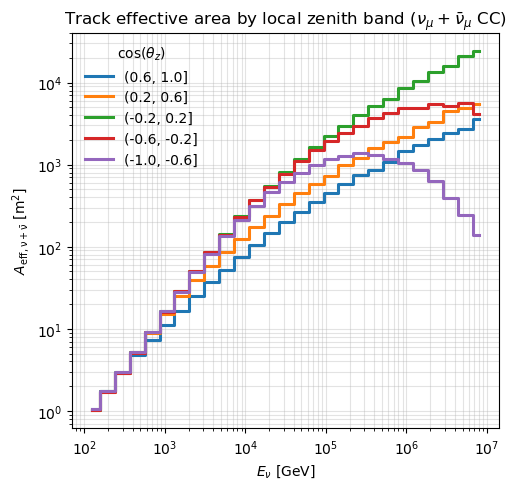

In [14]:
COS_ZENITH_BANDS = [
    (0.6, 1.0),
    (0.2, 0.6),
    (-0.2, 0.2),
    (-0.6, -0.2),
    (-1.0, -0.6),
]

BAND_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]


def effective_area_by_energy(data, energy_bins, cos_min, cos_max):
    band = data[(data["cos_zenith"] >= cos_min) & (data["cos_zenith"] < cos_max)]
    if band.empty:
        energy_bins = np.asarray(energy_bins, dtype=float)
        centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
        nan = np.full(len(centers), np.nan)
        return centers, nan, nan, np.zeros(len(centers), dtype=int)

    energy = band["energy"].to_numpy(dtype=float)
    weight = band["final_weight"].to_numpy(dtype=float)

    sum_weight, _ = np.histogram(energy, bins=energy_bins, weights=weight)
    sum_weight2, _ = np.histogram(energy, bins=energy_bins, weights=weight**2)
    counts, _ = np.histogram(energy, bins=energy_bins)

    delta_energy = np.diff(energy_bins)
    delta_omega = 2 * np.pi * (cos_max - cos_min)

    aeff_cm2 = sum_weight / (delta_energy * delta_omega)
    aeff_unc_cm2 = np.sqrt(sum_weight2) / (delta_energy * delta_omega)

    energy_bins = np.asarray(energy_bins, dtype=float)
    centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    return centers, aeff_cm2 / 1e4, aeff_unc_cm2 / 1e4, counts


def plot_zenith_banded_effective_area(data, title, energy_bins=None, show_uncertainty=False):
    data = data.copy()
    data = data[np.isfinite(data["energy"]) & (data["energy"] > 0)]

    if energy_bins is None:
        energy_bins = np.logspace(np.log10(data["energy"].min()), np.log10(data["energy"].max()), 28)

    fig, ax = plt.subplots(figsize=(5.2, 5.0))

    for (cos_min, cos_max), color in zip(COS_ZENITH_BANDS, BAND_COLORS):
        centers, aeff, aeff_unc, counts = effective_area_by_energy(data, energy_bins, cos_min, cos_max)
        positive = np.isfinite(aeff) & (aeff > 0) & (counts > 0)
        label = f"({cos_min:.1f}, {cos_max:.1f}]"

        ax.step(centers[positive], aeff[positive], where="mid", color=color, linewidth=2.2, label=label)
        if show_uncertainty:
            lower = np.maximum(aeff - aeff_unc, np.nextafter(0, 1))
            upper = aeff + aeff_unc
            ax.fill_between(centers[positive], lower[positive], upper[positive], step="mid", color=color, alpha=0.18)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_ylabel(r"$A_{\rm eff,\nu+\bar{\nu}}$ [m$^2$]")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.35)
    ax.legend(title=r"$\cos(\theta_z)$", frameon=False)
    fig.tight_layout()
    return fig, ax


# Left-panel style track effective area: muon CC is the track sample.
track_weights = weights_all[(weights_all["sample"] == "muon_cc") & (weights_all["interaction"] == "CC")]
fig, ax = plot_zenith_banded_effective_area(
    track_weights,
    title=r"Track effective area by local zenith band ($\nu_\mu + \bar{\nu}_\mu$ CC)",
    show_uncertainty=False,
)
plt.show()


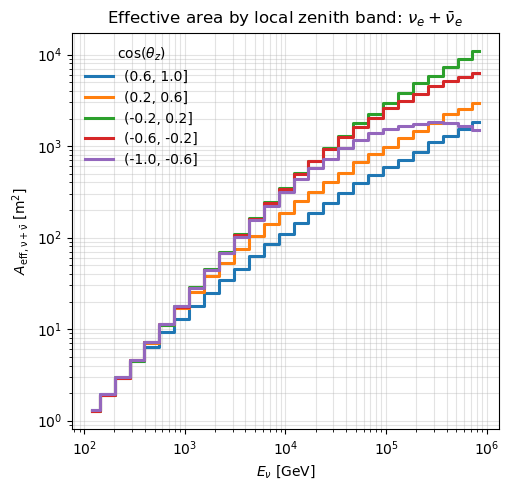

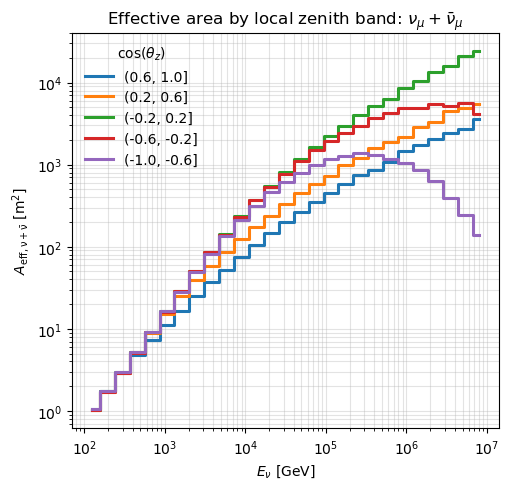

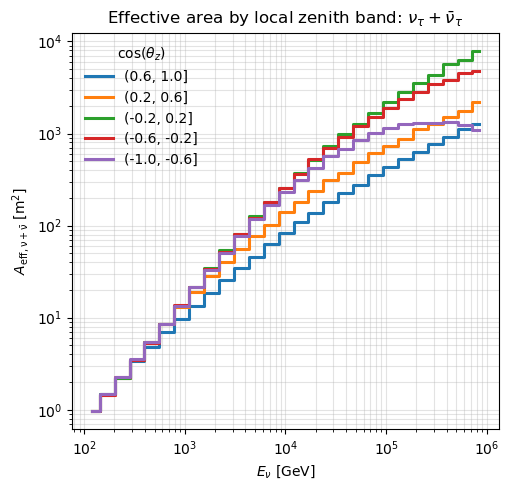

In [15]:
# Optional: same angular-banded effective-area plot for each flavor, using all available CC + NC weights.
for flavor, flavor_data in weights_all.groupby("flavor"):
    if flavor not in FLAVOR_LABELS:
        continue
    fig, ax = plot_zenith_banded_effective_area(
        flavor_data,
        title=f"Effective area by local zenith band: {FLAVOR_LABELS[flavor]}",
        show_uncertainty=False,
    )
    plt.show()


## Gen2-style two-panel summary

This makes a compact two-panel figure in the spirit of the reference plot:

- Left: track-like effective area from the muon CC sample, split by local `cos(zenith)` bands.
- Right: all-sky flavor effective area. Solid lines show available CC samples. Dashed lines show available NC samples. In the current `String340MC` files, `NC_LIW.csv` contains electron-flavor NC only, so only the electron dashed NC curve appears.


In [ ]:
FLAVOR_COLORS = {
    "e": "tab:blue",
    "mu": "tab:orange",
    "tau": "tab:green",
}


def effective_area_all_sky(data, energy_bins):
    data = data[np.isfinite(data["energy"]) & (data["energy"] > 0)].copy()
    energy = data["energy"].to_numpy(dtype=float)
    weight = data["final_weight"].to_numpy(dtype=float)
    energy_bins = np.asarray(energy_bins, dtype=float)

    sum_weight, _ = np.histogram(energy, bins=energy_bins, weights=weight)
    sum_weight2, _ = np.histogram(energy, bins=energy_bins, weights=weight**2)
    counts, _ = np.histogram(energy, bins=energy_bins)

    delta_energy = np.diff(energy_bins)
    delta_omega = 4 * np.pi

    aeff_cm2 = sum_weight / (delta_energy * delta_omega)
    aeff_unc_cm2 = np.sqrt(sum_weight2) / (delta_energy * delta_omega)
    centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    return centers, aeff_cm2 / 1e4, aeff_unc_cm2 / 1e4, counts


def add_track_zenith_panel(ax, data, energy_bins):
    for (cos_min, cos_max), color in zip(COS_ZENITH_BANDS, BAND_COLORS):
        centers, aeff, aeff_unc, counts = effective_area_by_energy(data, energy_bins, cos_min, cos_max)
        positive = np.isfinite(aeff) & (aeff > 0) & (counts > 0)
        ax.step(
            centers[positive],
            aeff[positive],
            where="mid",
            color=color,
            linewidth=2.0,
            label=f"({cos_min:.1f}, {cos_max:.1f}]",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_ylabel(r"$A_{\rm eff,\nu+\bar{\nu}}$ [m$^2$]")
    ax.set_title("Track effective area")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend(title=r"$\cos(\theta_z)$", frameon=False, fontsize=9, title_fontsize=10)


def add_flavor_panel(ax, data, energy_bins):
    cc_samples = {
        "e": "electron_cc",
        "mu": "muon_cc",
        "tau": "tau_cc",
    }

    for flavor, sample in cc_samples.items():
        flavor_data = data[(data["sample"] == sample) & (data["flavor"] == flavor)]
        centers, aeff, aeff_unc, counts = effective_area_all_sky(flavor_data, energy_bins)
        positive = np.isfinite(aeff) & (aeff > 0) & (counts > 0)
        ax.step(
            centers[positive],
            aeff[positive],
            where="mid",
            color=FLAVOR_COLORS[flavor],
            linewidth=2.2,
            linestyle="-",
            label=f"{flavor} CC",
        )

    nc_data = data[data["interaction"] == "NC"]
    for flavor, flavor_data in nc_data.groupby("flavor"):
        if flavor not in FLAVOR_COLORS:
            continue
        centers, aeff, aeff_unc, counts = effective_area_all_sky(flavor_data, energy_bins)
        positive = np.isfinite(aeff) & (aeff > 0) & (counts > 0)
        ax.step(
            centers[positive],
            aeff[positive],
            where="mid",
            color=FLAVOR_COLORS[flavor],
            linewidth=2.2,
            linestyle="--",
            label=f"{flavor} NC",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_ylabel(r"$A_{\rm eff,\nu+\bar{\nu}}$ [m$^2$]")
    ax.set_title("Flavor effective area")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend(frameon=False, fontsize=9)


summary_energy = weights_all["energy"].to_numpy(dtype=float)
summary_energy = summary_energy[np.isfinite(summary_energy) & (summary_energy > 0)]
summary_energy_bins = np.logspace(np.log10(summary_energy.min()), np.log10(summary_energy.max()), 28)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8), sharey=True)
add_track_zenith_panel(axes[0], track_weights, summary_energy_bins)
add_flavor_panel(axes[1], weights_all, summary_energy_bins)
fig.suptitle("String340MC generation-level effective area", y=1.02)
fig.tight_layout()
plt.show()
